In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import zipfile

zip_path = '/content/drive/MyDrive/preprocessed_photos 1.zip'
extract_path = '/content/yelp_images'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [3]:
import pandas as pd

train_df = pd.read_csv('/content/drive/MyDrive/train_data.csv')
test_df = pd.read_csv('/content/drive/MyDrive/test_data.csv')


In [5]:
train_df['label_encoded'] = train_df['label_encoded'].astype(str)
test_df['label_encoded'] = test_df['label_encoded'].astype(str)


In [6]:
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='/content/yelp_images',
    x_col='preprocessed_path',
    y_col='label_encoded',
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)


Found 159995 validated image filenames belonging to 5 classes.


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='/content/yelp_images',
    x_col='preprocessed_path',
    y_col='label_encoded',
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory='/content/yelp_images',
    x_col='preprocessed_path',
    y_col='label_encoded',
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)


Found 159995 validated image filenames belonging to 5 classes.
Found 39999 validated image filenames belonging to 5 classes.


In [8]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout

vgg_base = VGG16(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
for layer in vgg_base.layers:
    layer.trainable = False

x = Flatten()(vgg_base.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
output = Dense(5, activation='softmax')(x)

model = Model(inputs=vgg_base.input, outputs=output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,771,973 (60.17 MB)

 Trainable params: 1,057,285 (4.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=4
)


Epoch 1/4


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 402s 79ms/step - accuracy: 0.8435 - loss: 0.4489 - val_accuracy: 0.8992 - val_loss: 0.2933
Epoch 2/4
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 384s 77ms/step - accuracy: 0.8910 - loss: 0.3146 - val_accuracy: 0.8950 - val_loss: 0.3029
Epoch 3/4
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 387s 77ms/step - accuracy: 0.9002 - loss: 0.2886 - val_accuracy: 0.9076 - val_loss: 0.2846
Epoch 4/4
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 386s 77ms/step - accuracy: 0.9026 - loss: 0.2757 - val_accuracy: 0.9047 - val_loss: 0.2858


In [10]:
import numpy as np

y_pred_probs = model.predict(test_gen, verbose=1)

y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_gen.classes


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 64ms/step


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.60      0.72      3134
           1       0.94      0.98      0.96     21609
           2       0.84      0.94      0.89     11206
           3       0.87      0.72      0.79       336
           4       0.92      0.66      0.77      3714

    accuracy                           0.90     39999
   macro avg       0.90      0.78      0.82     39999
weighted avg       0.91      0.90      0.90     39999



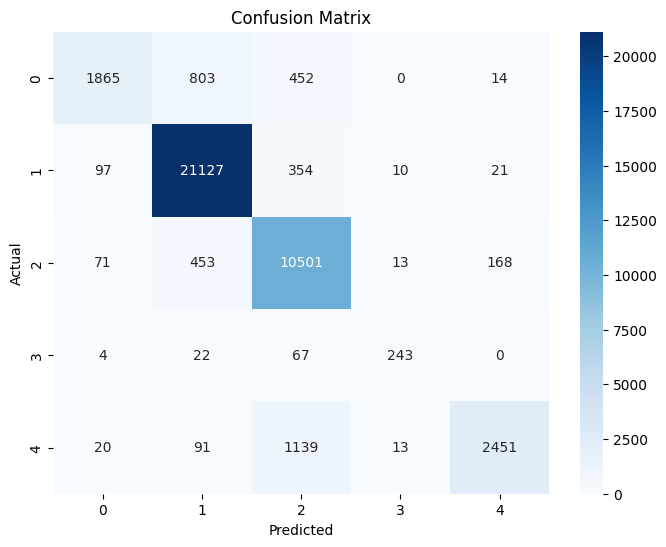

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Classification Report:")
print(classification_report(y_true, y_pred))

                                    #  confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
